<a href="https://colab.research.google.com/github/adamkubi456/polish-housing-market-eda/blob/main/polish_housing_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Libraries & Dependencies

In [116]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata
from google.colab import files
import matplotlib.ticker as ticker
from statsmodels.nonparametric.smoothers_lowess import lowess
import shutil
import plotly.express as px
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

### Loading Data into DataFrame

In [96]:
os.makedirs('assets', exist_ok=True)
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

path = kagglehub.dataset_download("krzysztofjamroz/apartment-prices-in-poland")

file_name = "apartments_pl_2024_06.csv"
file_path = os.path.join(path, file_name)

df = pd.read_csv(file_path)

Using Colab cache for faster access to the 'apartment-prices-in-poland' dataset.


### Dataset Overview

In [97]:
df.head()

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,811891f98a870dfd6e414374a0a85560,szczecin,blockOfFlats,47.00,2.0,6.0,12.0,1981.0,53.428544,14.552812,...,0.085,condominium,concreteSlab,NaN,no,yes,yes,no,yes,449000
1,adaf636d0c44d8d9325bce42403eefee,szczecin,apartmentBuilding,88.22,3.0,1.0,2.0,2000.0,53.449093,14.516844,...,0.668,condominium,brick,premium,yes,yes,no,no,no,950000
2,9b957bd60885a469c96f17b58a914f4b,szczecin,apartmentBuilding,117.00,5.0,4.0,4.0,NaN,53.443096,14.561348,...,0.229,udział,brick,premium,yes,yes,no,no,no,1099000
3,74fef2ff7135bc70797a3fbfd7d44ed6,szczecin,blockOfFlats,33.31,1.0,1.0,4.0,1963.0,53.436100,14.541200,...,0.388,cooperative,brick,NaN,yes,no,no,yes,yes,380000
4,77cc78c75b0d09bf84d6d3124a28803c,szczecin,blockOfFlats,56.00,3.0,7.0,7.0,2018.0,53.447465,14.557811,...,0.178,condominium,brick,premium,yes,yes,yes,yes,yes,799000


In [ ]:
df.describe()

,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,price
count,21501.000000,21501.000000,17928.000000,21292.000000,18121.000000,21501.000000,21501.000000,21501.000000,21501.000000,21490.000000,21438.000000,21481.000000,21482.000000,21470.000000,20917.000000,21471.000000,2.150100e+04
mean,56.968572,2.622948,3.404786,5.474826,1986.774129,51.992750,19.496174,4.431978,20.542951,0.407994,0.970949,0.510007,0.357013,0.335759,1.440711,0.347109,8.238679e+05
std,20.617717,0.892924,2.606225,3.407545,32.796668,1.313801,1.754150,2.783001,23.905646,0.442670,0.882206,0.474219,0.414213,0.433327,1.103795,0.427962,4.311267e+05
min,25.000000,1.000000,1.000000,1.000000,1850.000000,49.982066,14.447127,0.020000,0.000000,0.005000,0.005000,0.002000,0.001000,0.001000,0.006000,0.001000,1.910000e+05
25%,42.690000,2.000000,2.000000,3.000000,1969.000000,51.103600,18.539977,2.130000,7.000000,0.178000,0.361000,0.238000,0.154000,0.112000,0.565000,0.136000,5.490000e+05
50%,52.810000,3.000000,3.000000,4.000000,1993.000000,52.194157,19.914700,4.130000,14.000000,0.289000,0.677000,0.392000,0.256000,0.224000,1.121000,0.235000,7.218240e+05
75%,66.300000,3.000000,4.000000,7.000000,2016.000000,52.379000,20.988591,6.250000,24.000000,0.462000,1.244000,0.621000,0.411000,0.402000,2.050000,0.403000,9.650000e+05
max,150.000000,6.000000,29.000000,29.000000,2024.000000,54.582870,23.208873,16.480000,212.000000,4.920000,4.918000,4.801000,4.767000,4.928000,5.000000,4.802000,3.000000e+06


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21501 entries, 0 to 21500
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    21501 non-null  object 
 1   city                  21501 non-null  object 
 2   type                  17104 non-null  object 
 3   squareMeters          21501 non-null  float64
 4   rooms                 21501 non-null  float64
 5   floor                 17928 non-null  float64
 6   floorCount            21292 non-null  float64
 7   buildYear             18121 non-null  float64
 8   latitude              21501 non-null  float64
 9   longitude             21501 non-null  float64
 10  centreDistance        21501 non-null  float64
 11  poiCount              21501 non-null  float64
 12  schoolDistance        21490 non-null  float64
 13  clinicDistance        21438 non-null  float64
 14  postOfficeDistance    21481 non-null  float64
 15  kindergartenDistanc

### Missing Values Summary

In [98]:
pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percentage [%]': (df.isna().mean() * 100).round(2)
})

,Missing Count,Missing Percentage [%]
id,0,0.00
city,0,0.00
type,4397,20.45
squareMeters,0,0.00
rooms,0,0.00
floor,3573,16.62
floorCount,209,0.97
buildYear,3380,15.72
latitude,0,0.00
longitude,0,0.00


### Categorical Missing Values

In [99]:
df['condition'] = df['condition'].fillna('Missing')
df['type'] = df['type'].fillna('Missing')
df['buildingMaterial'] = df['buildingMaterial'].fillna('Missing')
df['hasElevator'] = df['hasElevator'].fillna('Missing')

### Numerical Missing Values (Group-based Imputation)

In [100]:
def impute_group(series):
    existing = series.dropna()
    if len(existing) == 0:
        return series
    mask = series.isna()
    series.loc[mask] = np.random.choice(existing, size=mask.sum())
    return series

In [101]:
df['floorCount'] = (
    df.groupby(['city', 'type'])['floorCount']
    .transform(impute_group)
)

df['floor'] = (
    df.groupby(['type', 'floorCount'])['floor']
    .transform(impute_group)
)

df['buildYear'] = (
    df.groupby(['city', 'type', 'buildingMaterial'])['buildYear']
    .transform(impute_group)
)

#Fallback for 18 rows where all records lacked build year within the group
df['buildYear'] = (
    df.groupby(['type', 'buildingMaterial'])['buildYear']
    .transform(impute_group)
)

In [102]:
def fill_median(series):
    return series.fillna(series.median())

distance_cols = [
    'schoolDistance',
    'clinicDistance',
    'postOfficeDistance',
    'kindergartenDistance',
    'restaurantDistance',
    'collegeDistance',
    'pharmacyDistance',
]

for col in distance_cols:
    df[col] = df.groupby('city')[col].transform(fill_median)

### Feature Engineering

In [103]:
amenities_cols = ['hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity', 'hasStorageRoom']
map_dict = {
    'yes': 1, 'no': 0,
    'true': 1, 'false': 0,
    True: 1, False: 0,
    '1': 1, '0': 0,
    1: 1, 0: 0
}

for col in amenities_cols:
    df[col] = df[col].astype(str).str.strip().str.lower().map(map_dict).fillna(0).astype(int)

df['price_per_m2'] = (df['price'] / df['squareMeters']).round(2)
df['avg_room_size'] = (df['squareMeters'] / df['rooms']).round(2)
df['is_ground_floor'] = (df['floor'] == 1).astype(int)
df['is_top_floor'] = (df['floor'] == df['floorCount']).astype(int)

era_bins = [-np.inf, 1945, 1989, 2010, np.inf]
era_labels = ['Pre-war', 'Communist bloc', 'Post-transition', 'Modern']
df['building_era'] = pd.cut(df['buildYear'], bins=era_bins, labels=era_labels)

df['amenities_score'] = df[amenities_cols].sum(axis=1)

In [104]:
preview_cols = ['price_per_m2','avg_room_size', 'is_ground_floor', 'is_top_floor', 'building_era', 'amenities_score']
print(df[preview_cols].head())

   price_per_m2  avg_room_size  is_ground_floor  is_top_floor  \
0       9553.19          23.50                0             0   
1      10768.53          29.41                1             0   
2       9393.16          23.40                0             1   
3      11407.99          33.31                1             0   
4      14267.86          18.67                0             1   

      building_era  amenities_score  
0   Communist bloc                3  
1  Post-transition                2  
2           Modern                2  
3   Communist bloc                3  
4           Modern                5  


### Outlier Detection and Anomaly Verification

In [105]:
num_cols = [
    'price', 'squareMeters', 'rooms', 'floor',
    'floorCount', 'buildYear', 'centreDistance', 'price_per_m2'
]

def find_outliers_iqr(data: pd.DataFrame, columns: list, factor: float = 1.5) -> pd.DataFrame:
    summary = []
    for col in columns:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        lower_limit = q1 - factor * iqr
        upper_limit = q3 + factor * iqr

        outliers_mask = (data[col] < lower_limit) | (data[col] > upper_limit)
        outlier_count = outliers_mask.sum()

        summary.append({
            'Column': col,
            'Min': round(data[col].min(), 2),
            'Lower Bound': round(lower_limit, 2),
            'Median': round(data[col].median(), 2),
            'Upper Bound': round(upper_limit, 2),
            'Max': round(data[col].max(), 2),
            'Outlier Count': outlier_count,
            'Percentage [%]': round(outlier_count / len(data) * 100, 2)
        })

    return pd.DataFrame(summary)

outliers_summary = find_outliers_iqr(df, num_cols)
print(outliers_summary.to_string(index=False))

        Column       Min  Lower Bound    Median  Upper Bound        Max  Outlier Count  Percentage [%]
         price 191000.00    -75000.00 721824.00   1589000.00 3000000.00           1355            6.30
  squareMeters     25.00         7.27     52.81       101.72     150.00            901            4.19
         rooms      1.00         0.50      3.00         4.50       6.00            637            2.96
         floor      1.00        -1.00      3.00         7.00      29.00           1584            7.37
    floorCount      1.00        -3.00      4.00        13.00      29.00            650            3.02
     buildYear   1850.00      1896.00   1991.00      2088.00    2024.00            170            0.79
centreDistance      0.02        -4.05      4.13        12.43      16.48            146            0.68
  price_per_m2   4471.91      -390.25  14265.93     28963.43   30702.75            144            0.67


In [106]:
context_cols = ['city', 'price', 'squareMeters', 'price_per_m2', 'rooms', 'floor', 'buildYear', 'condition', 'centreDistance']

print("=" * 60)
print("TOP 10: HIGHEST PRICE PER M² (suspected price or area entry error)")
print("=" * 60)
top_expensive_m2 = df.sort_values(by='price_per_m2', ascending=False)[context_cols].head(10)
print(top_expensive_m2.to_string())

print("\n" + "=" * 60)
print("TOP 10: LOWEST PRICE PER M² (suspected underpricing or entry error)")
print("=" * 60)
top_cheap_m2 = df.sort_values(by='price_per_m2', ascending=True)[context_cols].head(10)
print(top_cheap_m2.to_string())

TOP 10: HIGHEST PRICE PER M² (suspected price or area entry error)
           city    price  squareMeters  price_per_m2  rooms  floor  buildYear condition  centreDistance
20467  warszawa  1350000         43.97      30702.75    2.0    3.0     1937.0   Missing            2.13
18554  warszawa  1970000         64.27      30651.94    3.0    1.0     1984.0   Missing            2.26
13830  warszawa  1970000         64.27      30651.94    3.0    1.0     1984.0   premium            2.28
18864  warszawa  2450000         80.00      30625.00    3.0    1.0     1998.0   Missing            2.16
20428  warszawa  1500000         49.00      30612.24    2.0    2.0     2016.0   Missing            4.03
1368     gdynia  1295000         42.36      30571.29    2.0    2.0     2016.0   Missing            4.56
15511  warszawa  2995000         98.05      30545.64    3.0    1.0     1923.0   Missing            3.29
18742  warszawa  1128500         37.00      30500.00    2.0    6.0     2015.0   Missing            4.

### Hypothesis 1: Amenities Bundle Premium & Saturation Effect

/tmp/ipykernel_999/104549828.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




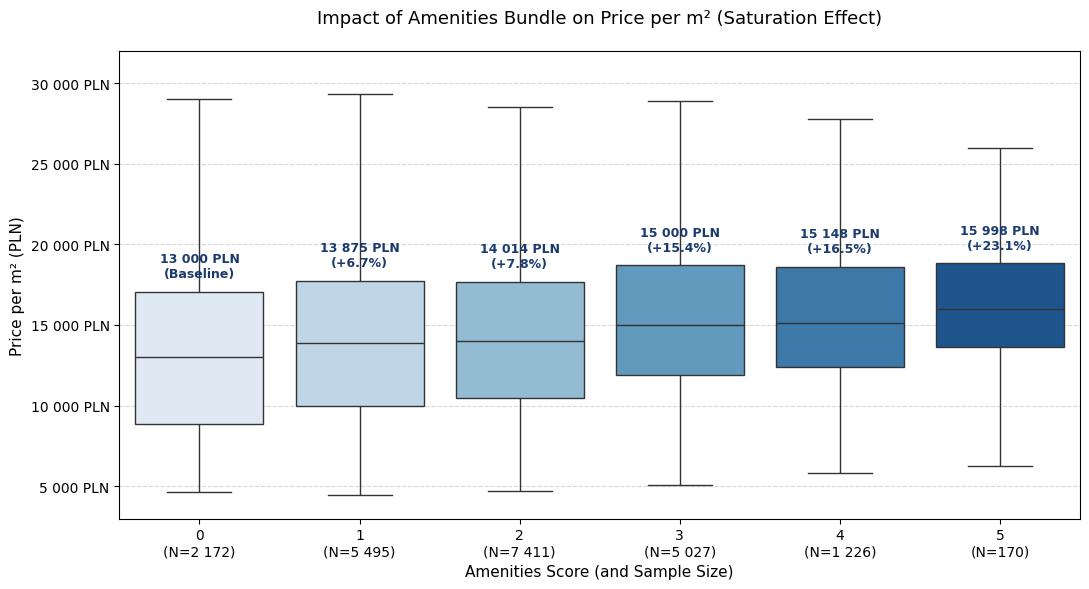

In [107]:
stats = df.groupby('amenities_score')['price_per_m2'].agg(
    median_val='median',
    n_count='count'
).reset_index()

base_median = stats.loc[stats['amenities_score'] == 0, 'median_val'].values[0]
stats['pct_change'] = ((stats['median_val'] / base_median - 1) * 100).round(1)

labels_with_n = [f"{int(row['amenities_score'])}\n(N={int(row['n_count']):,})".replace(',', ' ') for _, row in stats.iterrows()]

plt.figure(figsize=(11, 6))
ax = sns.boxplot(
    data=df,
    x='amenities_score',
    y='price_per_m2',
    palette='Blues',
    showfliers=False
)

q3_values = df.groupby('amenities_score')['price_per_m2'].quantile(0.75).values
for i, row in stats.iterrows():
    premium_txt = f"+{row['pct_change']}%" if row['pct_change'] > 0 else "Baseline"
    label = f"{int(row['median_val']):,} PLN\n({premium_txt})".replace(',', ' ')
    ax.text(
        i, q3_values[i] + 700, label,
        ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1b3b6f'
    )

plt.title('Impact of Amenities Bundle on Price per m² (Saturation Effect)', fontsize=13, pad=20)
plt.xlabel('Amenities Score (and Sample Size)', fontsize=11)
plt.ylabel('Price per m² (PLN)', fontsize=11)
plt.xticks(ticks=range(len(labels_with_n)), labels=labels_with_n)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,} PLN".replace(',', ' ')))
plt.ylim(3000, 32000)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('assets/h1_amenities_premium.png', dpi=300, bbox_inches='tight')
plt.show()

### Hypothesis 2: Micro-Apartment Premium & Size Scaling Effect

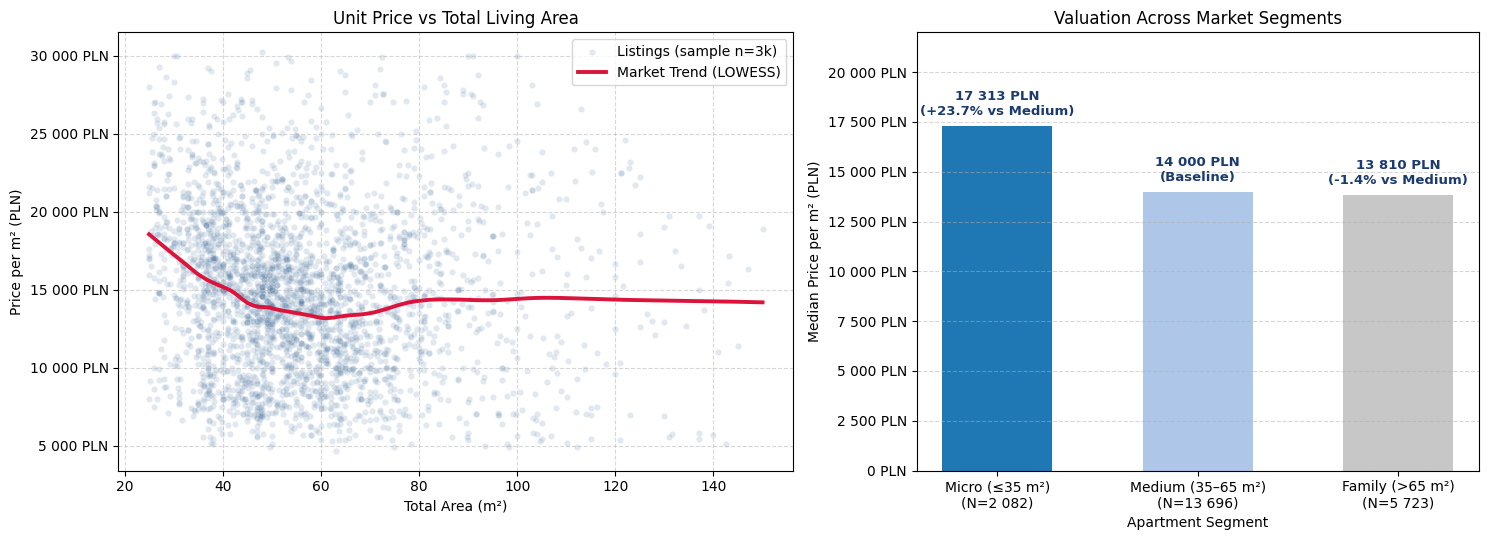

In [108]:
size_bins = [0, 35, 65, np.inf]
size_labels = ['Micro (≤35 m²)', 'Medium (35–65 m²)', 'Family (>65 m²)']
df['apartment_segment'] = pd.cut(df['squareMeters'], bins=size_bins, labels=size_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1.2, 1]})

sample_df = df.sample(n=min(3000, len(df)), random_state=42)
sns.scatterplot(
    data=sample_df, x='squareMeters', y='price_per_m2',
    alpha=0.15, color='#3b6998', s=20, ax=ax1, label='Listings (sample n=3k)'
)

smooth_trend = lowess(df['price_per_m2'], df['squareMeters'], frac=0.25)
ax1.plot(smooth_trend[:, 0], smooth_trend[:, 1], color='crimson', linewidth=2.8, label='Market Trend (LOWESS)')

ax1.set_title('Unit Price vs Total Living Area', fontsize=12)
ax1.set_xlabel('Total Area (m²)', fontsize=10)
ax1.set_ylabel('Price per m² (PLN)', fontsize=10)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,} PLN".replace(',', ' ')))
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

segment_stats = df.groupby('apartment_segment', observed=False)['price_per_m2'].agg(
    median_val='median', count_val='count'
).reset_index()

labels_with_n = [f"{row['apartment_segment']}\n(N={row['count_val']:,})".replace(',', ' ') for _, row in segment_stats.iterrows()]

bars = ax2.bar(
    range(len(segment_stats)),
    segment_stats['median_val'],
    color=['#1f77b4', '#aec7e8', '#c7c7c7'],
    width=0.55
)

base_price = segment_stats.loc[segment_stats['apartment_segment'] == 'Medium (35–65 m²)', 'median_val'].values[0]
for bar, (_, row) in zip(bars, segment_stats.iterrows()):
    val = row['median_val']
    pct_diff = ((val / base_price) - 1) * 100
    pct_text = f"+{pct_diff:.1f}% vs Medium" if pct_diff > 0 else (f"{pct_diff:.1f}% vs Medium" if pct_diff < 0 else "Baseline")

    ax2.text(
        bar.get_x() + bar.get_width()/2, val + 400,
        f"{int(val):,} PLN\n({pct_text})".replace(',', ' '),
        ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#1b3b6f'
    )

ax2.set_title('Valuation Across Market Segments', fontsize=12)
ax2.set_xlabel('Apartment Segment', fontsize=10)
ax2.set_ylabel('Median Price per m² (PLN)', fontsize=10)
ax2.set_xticks(range(len(labels_with_n)))
ax2.set_xticklabels(labels_with_n)
ax2.set_ylim(0, 22000)

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,} PLN".replace(',', ' ')))
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('assets/h2_micro_apartments.png', dpi=300, bbox_inches='tight')
plt.show()

### Hypothesis 3: Room Density vs Unit Valuation (45–65 m²)

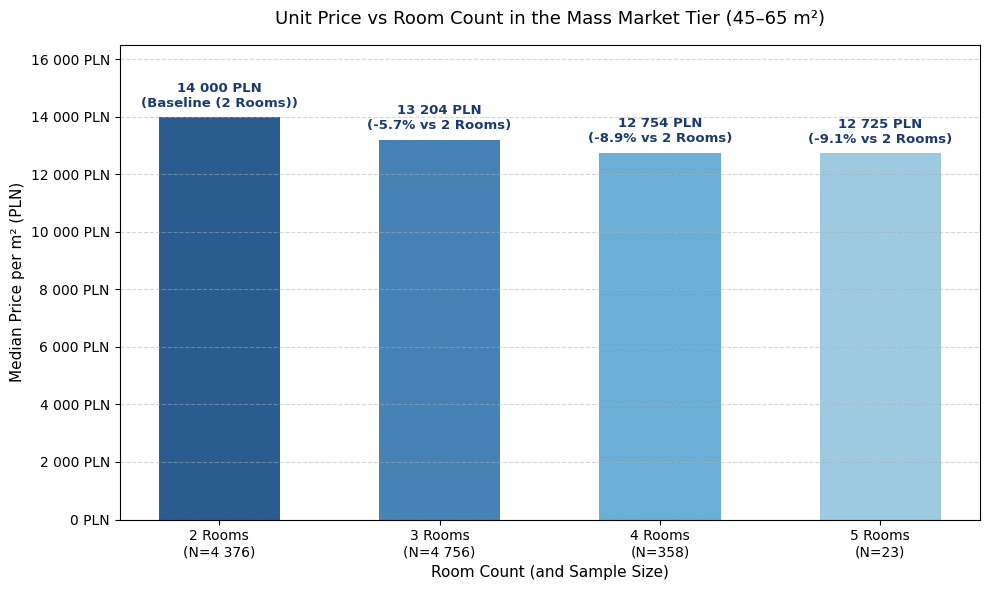

In [109]:
mid_segment = df[(df['squareMeters'] >= 45) & (df['squareMeters'] <= 65)].copy()

stats_rooms = mid_segment.groupby('rooms', observed=False)['price_per_m2'].agg(
    mediana='median',
    count='count'
).reset_index()

stats_rooms = stats_rooms[stats_rooms['count'] >= 10]

labels_with_n = [f"{int(row['rooms'])} Rooms\n(N={int(row['count']):,})".replace(',', ' ') for _, row in stats_rooms.iterrows()]

plt.figure(figsize=(10, 6))
bars = plt.bar(
    range(len(stats_rooms)),
    stats_rooms['mediana'],
    color=['#2b5c8f', '#4682b4', '#6baed6', '#9ecae1'][:len(stats_rooms)],
    width=0.55
)

base_price = stats_rooms.loc[stats_rooms['rooms'] == 2, 'mediana'].values[0]

for bar, (_, row) in zip(bars, stats_rooms.iterrows()):
    val = row['mediana']
    pct_diff = ((val / base_price) - 1) * 100
    pct_text = "Baseline (2 Rooms)" if row['rooms'] == 2 else f"{pct_diff:.1f}% vs 2 Rooms"

    plt.text(
        bar.get_x() + bar.get_width() / 2, val + 250,
        f"{int(val):,} PLN\n({pct_text})".replace(',', ' '),
        ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#1b3b6f'
    )

plt.title('Unit Price vs Room Count in the Mass Market Tier (45–65 m²)', fontsize=13, pad=15)
plt.xlabel('Room Count (and Sample Size)', fontsize=11)
plt.ylabel('Median Price per m² (PLN)', fontsize=11)
plt.xticks(range(len(stats_rooms)), labels_with_n)
plt.ylim(0, 16500)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,} PLN".replace(',', ' ')))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('assets/h3_room_density.png', dpi=300, bbox_inches='tight')
plt.show()

In [110]:
era_room_comparison = mid_segment[mid_segment['rooms'].isin([2, 3])].groupby(
    ['building_era', 'rooms'], observed=False
)['price_per_m2'].agg(median='median', count='count').reset_index()

print("--- Median price per m² for 2 vs 3 rooms by building era ---")
print(era_room_comparison)

--- Median price per m² for 2 vs 3 rooms by building era ---
      building_era  rooms     median  count
0          Pre-war    2.0  11780.250    504
1          Pre-war    3.0  12909.965    252
2   Communist bloc    2.0  12557.650   1557
3   Communist bloc    3.0  12452.765   2350
4  Post-transition    2.0  14221.155   1028
5  Post-transition    3.0  12809.490    659
6           Modern    2.0  16046.510   1287
7           Modern    3.0  14555.120   1495


### Hypothesis 4: Student Market Resilience to Property Condition

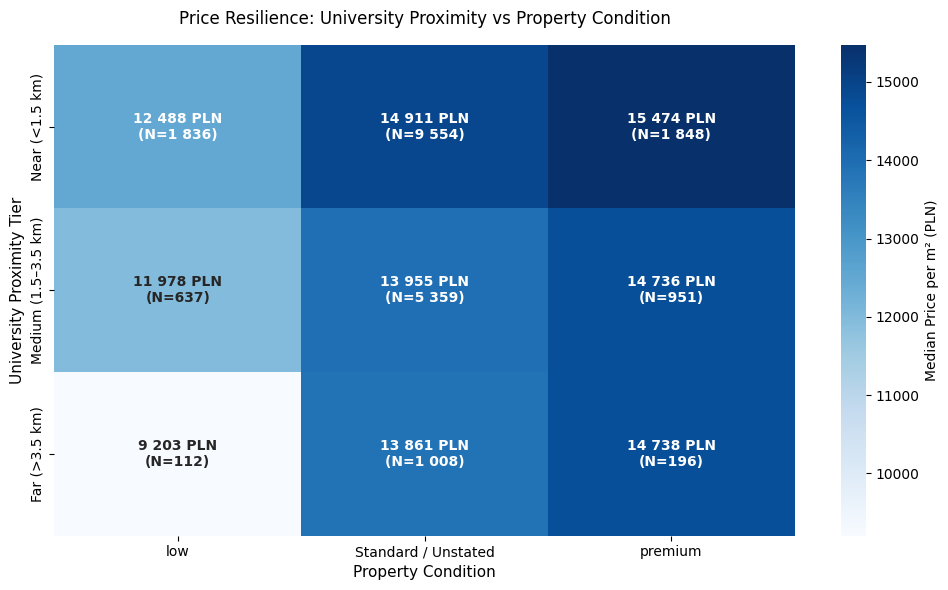

In [111]:
df_plot = df.copy()

college_bins = [0, 1.5, 3.5, np.inf]
college_labels = ['Near (<1.5 km)', 'Medium (1.5–3.5 km)', 'Far (>3.5 km)']
df_plot['college_zone'] = pd.cut(
    df_plot['collegeDistance'],
    bins=college_bins,
    labels=college_labels
)

df_plot['condition_clean'] = df_plot['condition'].replace({
    'Missing': 'Standard / Unstated',
    'Brak danych': 'Standard / Unstated'
})

pivot_price = df_plot.pivot_table(
    index='college_zone',
    columns='condition_clean',
    values='price_per_m2',
    aggfunc='median',
    observed=False
)

pivot_counts = df_plot.pivot_table(
    index='college_zone',
    columns='condition_clean',
    values='price_per_m2',
    aggfunc='count',
    observed=False
)

order_cols = [c for c in ['low', 'Standard / Unstated', 'premium'] if c in pivot_price.columns]
pivot_price = pivot_price[order_cols]
pivot_counts = pivot_counts[order_cols]

annot_matrix = np.empty(pivot_price.shape, dtype=object)
for i in range(pivot_price.shape[0]):
    for j in range(pivot_price.shape[1]):
        val = pivot_price.iloc[i, j]
        cnt = pivot_counts.iloc[i, j]
        if pd.notna(val):
            annot_matrix[i, j] = f"{int(val):,} PLN\n(N={int(cnt):,})".replace(',', ' ')
        else:
            annot_matrix[i, j] = "N/A"

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_price,
    annot=annot_matrix,
    fmt='',
    cmap='Blues',
    cbar_kws={'label': 'Median Price per m² (PLN)'},
    annot_kws={'fontsize': 10, 'weight': 'bold'}
)

plt.title('Price Resilience: University Proximity vs Property Condition', fontsize=12, pad=15)
plt.xlabel('Property Condition', fontsize=11)
plt.ylabel('University Proximity Tier', fontsize=11)

plt.tight_layout()
plt.savefig('assets/h4_student_condition.png', dpi=300, bbox_inches='tight')
plt.show()

### Download Generated Assets

In [119]:
shutil.make_archive('assets', 'zip', 'assets')
files.download('assets.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Geospatial Analysis (Interactive Price Map – Warsaw)

In [120]:
city_name = 'warszawa'
df_map = df[df['city'].str.lower() == city_name].copy()

q_min, q_max = df_map['price_per_m2'].quantile([0.01, 0.99])
df_map['color_capped'] = df_map['price_per_m2'].clip(q_min, q_max)

fig = px.scatter_mapbox(
    df_map,
    lat='latitude',
    lon='longitude',
    color='color_capped',
    color_continuous_scale='Turbo',
    zoom=10.5,
    title=f'Spatial Distribution of Apartment Prices per m² ({city_name.capitalize()})',
    hover_name='city',
    hover_data={
        'latitude': False,
        'longitude': False,
        'color_capped': False,
        'price_per_m2': ':.0f',
        'price': ':.0f',
        'squareMeters': ':.1f',
        'rooms': True,
        'buildYear': True
    },
    labels={'color_capped': 'PLN / m²'}
)

fig.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[{
        "below": "traces",
        "sourcetype": "raster",
        "source": [
            "https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}"
        ],
        "sourceattribution": "Esri, HERE, Garmin"
    }],
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=650
)

fig.show()
fig.write_html('assets/warsaw_price_map.html', include_plotlyjs='cdn')

### Feature Correlation Matrix (Spearman Rank)

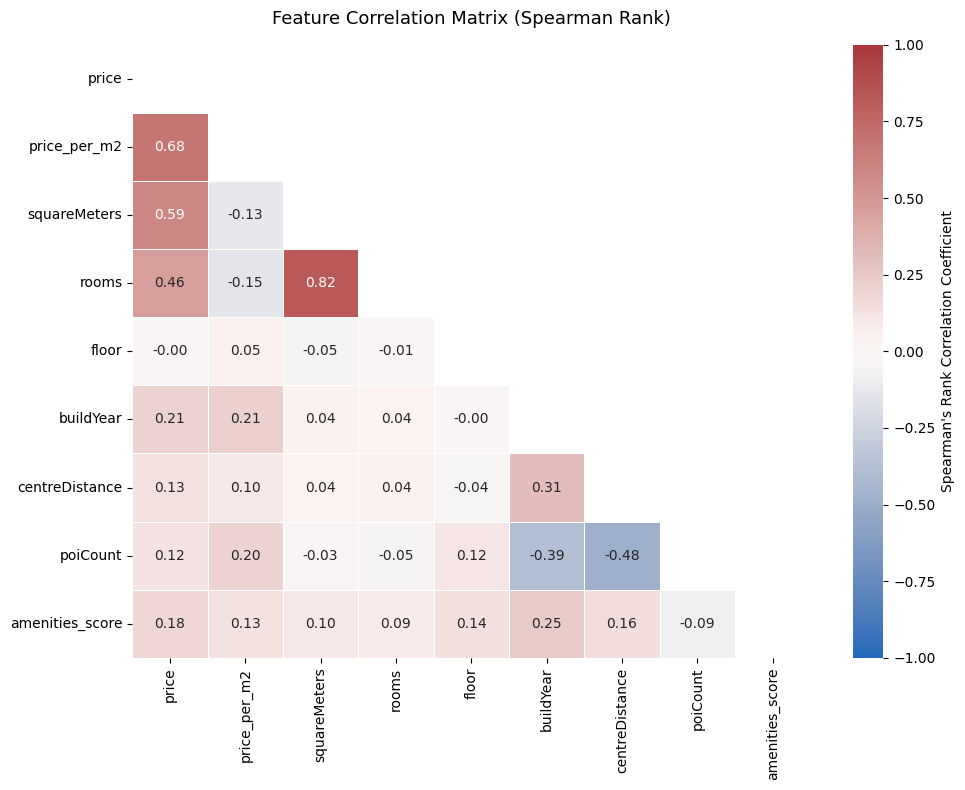

In [113]:
features_to_corr = [
    'price',
    'price_per_m2',
    'squareMeters',
    'rooms',
    'floor',
    'buildYear',
    'centreDistance',
    'poiCount',
    'amenities_score'
]

available_features = [col for col in features_to_corr if col in df.columns]
corr_matrix = df[available_features].corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    vmin=-1.0,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={'label': "Spearman's Rank Correlation Coefficient"}
)

plt.title('Feature Correlation Matrix (Spearman Rank)', fontsize=13, pad=15)
plt.tight_layout()

plt.savefig('assets/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Statistical Hypothesis Testing

In [118]:
results = []

amenity_groups = [group['price_per_m2'].values for _, group in df.groupby('amenities_score')]
stat_h1, p_h1 = kruskal(*amenity_groups)

results.append({
    'Hypothesis': 'H1: Amenities score effect (0-5)',
    'Test': 'Kruskal-Wallis H',
    'Statistic': round(stat_h1, 2),
    'p-value': f"{p_h1:.2e}",
    'Significant (alpha=0.05)': 'Yes' if p_h1 < 0.05 else 'No',
    'Verdict': 'Confirmed (diminishing returns)'
})

micro_prices = df[df['apartment_segment'].astype(str).str.contains('Micro|Mikro|≤35|do 35', regex=True)]['price_per_m2']
med_prices = df[df['apartment_segment'].astype(str).str.contains('Medium|Średnie|35.*65', regex=True)]['price_per_m2']

stat_h2, p_h2 = mannwhitneyu(micro_prices, med_prices, alternative='greater')

results.append({
    'Hypothesis': 'H2: Micro-apartment premium (≤35 vs 35-65 m²)',
    'Test': 'Mann-Whitney U',
    'Statistic': round(stat_h2, 2),
    'p-value': f"{p_h2:.2e}",
    'Significant (alpha=0.05)': 'Yes' if p_h2 < 0.05 else 'No',
    'Verdict': 'Confirmed (+23.7% premium)'
})

if 'mid_segment' not in locals():
    mid_segment = df[(df['squareMeters'] >= 45) & (df['squareMeters'] <= 65)]

p_2rooms = mid_segment[mid_segment['rooms'] == 2]['price_per_m2']
p_3rooms = mid_segment[mid_segment['rooms'] == 3]['price_per_m2']

stat_h3, p_h3 = mannwhitneyu(p_3rooms, p_2rooms, alternative='greater')

results.append({
    'Hypothesis': 'H3: Higher valuation for 3 vs 2 rooms (45-65 m²)',
    'Test': 'Mann-Whitney U',
    'Statistic': round(stat_h3, 2),
    'p-value': f"{p_h3:.2e}",
    'Significant (alpha=0.05)': 'No (reversed)',
    'Verdict': 'Rejected (2-room units lead by 5.7%)'
})

source_h4 = df_plot if 'df_plot' in locals() else df

low_condition = source_h4[source_h4['condition_clean'] == 'low']
low_near = low_condition[low_condition['college_zone'].astype(str).str.contains('Near|<1.5', regex=True)]['price_per_m2']
low_far = low_condition[low_condition['college_zone'].astype(str).str.contains('Far|>3.5', regex=True)]['price_per_m2']

stat_h4, p_h4 = mannwhitneyu(low_near, low_far, alternative='greater')

results.append({
    'Hypothesis': 'H4: University proximity protects low-condition units',
    'Test': 'Mann-Whitney U',
    'Statistic': round(stat_h4, 2),
    'p-value': f"{p_h4:.2e}",
    'Significant (alpha=0.05)': 'Yes' if p_h4 < 0.05 else 'No',
    'Verdict': 'Confirmed (+35.7% price cushion)'
})

summary_table = pd.DataFrame(results)
print(summary_table.to_string(index=False))

                                           Hypothesis             Test   Statistic   p-value Significant (alpha=0.05)                              Verdict
                     H1: Amenities score effect (0-5) Kruskal-Wallis H      386.58  2.32e-81                      Yes      Confirmed (diminishing returns)
        H2: Micro-apartment premium (≤35 vs 35-65 m²)   Mann-Whitney U 18604690.50 6.38e-112                      Yes           Confirmed (+23.7% premium)
     H3: Higher valuation for 3 vs 2 rooms (45-65 m²)   Mann-Whitney U  9241141.00  1.00e+00            No (reversed) Rejected (2-room units lead by 5.7%)
H4: University proximity protects low-condition units   Mann-Whitney U   128866.00  3.28e-06                      Yes     Confirmed (+35.7% price cushion)
